In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
movie=pd.read_csv('movie_preprocessed.csv')
movie.head(5)

,Unnamed: 0,budget,genres,id,keywords,original_language,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,status,tagline,title,vote_average,vote_count
0,0,15000000.0,"Action,Adventure,Fantasy,Science Fiction",19995.0,"culture clash,future,space war,space colony,so...",en,"In the 22nd century, a paraplegic Marine is di...",12.921594,"Ingenious Film Partners,Twentieth Century Fox ...","United States of America,United Kingdom",10-12-2009,19170001.0,103.0,Released,Enter the World of Pandora.,Avatar,7.2,235.0
1,1,15000000.0,"Adventure,Fantasy,Action",285.0,"ocean,drug abuse,exotic island,east india trad...",en,"Captain Barbossa, long believed to be dead, ha...",12.921594,"Walt Disney Pictures,Jerry Bruckheimer Films,S...",United States of America,19-05-2007,19170001.0,103.0,Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,235.0
2,2,15000000.0,"Action,Adventure,Crime",14629.0,"spy,based on novel,secret agent,sequel,mi6,bri...",en,A cryptic message from Bond’s past sends him o...,12.921594,"Columbia Pictures,Danjaq,B24","United Kingdom,United States of America",26-10-2015,19170001.0,148.0,Released,A Plan No One Escapes,Spectre,6.3,235.0
3,3,15000000.0,"Action,Crime,Drama,Thriller",49026.0,"dc comics,crime fighter,terrorist,secret ident...",en,Following the death of District Attorney Harve...,12.921594,"Legendary Pictures,Warner Bros,DC Entertainmen...",United States of America,16-07-2012,19170001.0,103.0,Released,The Legend Ends,The Dark Knight Rises,7.6,235.0
4,4,15000000.0,"Action,Adventure,Science Fiction",49529.0,"based on novel,mars,medallion,space travel,pri...",en,"John Carter is a war-weary, former military ca...",43.926995,Walt Disney Pictures,United States of America,07-03-2012,19170001.0,132.0,Released,"Lost in our world, found in another.",John Carter,6.1,235.0


In [3]:
movie.drop(columns=['Unnamed: 0'], inplace=True)

In [4]:
credit=pd.read_csv('credit_preprocessed.csv')
credit.head()

,Unnamed: 0,movie_id,title,cast,director,editor,production_design,art_direction,costume_design,original_music_composer,director_of_photography
0,0,19995,Avatar,"Sam Worthington,Zoe Saldana,Sigourney Weaver,S...",James Cameron,Stephen E. Rivkin,Rick Carter,Andrew Menzies,Deborah Lynn Scott,James Horner,Mauro Fiore
1,1,285,Pirates of the Caribbean At Worlds End,"Johnny Depp,Orlando Bloom,Keira Knightley,Stel...",Gore Verbinski,Stephen E. Rivkin,Rick Heinrichs,John Dexter,Liz Dann,Hans Zimmer,Dariusz Wolski
2,2,206647,Spectre,"Daniel Craig,Christoph Waltz,Léa Seydoux,Ralph...",Sam Mendes,Lee Smith,Dennis Gassner,Neal Callow,Jany Temime,Thomas Newman,Hoyte van Hoytema
3,3,49026,The Dark Knight Rises,"Christian Bale,Michael Caine,Gary Oldman,Anne ...",Christopher Nolan,Lee Smith,Nathan Crowley,Robert Woodruff,Lindy Hemming,Hans Zimmer,Wally Pfister
4,4,49529,John Carter,"Taylor Kitsch,Lynn Collins,Samantha Morton,Wil...",Andrew Stanton,Eric Zumbrunnen,Nathan Crowley,Robert Woodruff,Mayes C. Rubeo,Unknown,Daniel Mindel


In [5]:
credit.drop(columns=['Unnamed: 0'], inplace=True)

# Which is the most common keyword

In [6]:
movie['keywords'] = movie['keywords'].apply(lambda x: [k.strip() for k in str(x).split(',')] if pd.notna(x) else [])
movie['keywords'] = movie['keywords'].apply(lambda x: [k for k in x if k and k.lower() != 'unknown'])
movie_exploded = movie.explode('keywords')
keyword_count = movie_exploded['keywords'].value_counts()
print(keyword_count)

keywords
woman director          324
independent film        318
duringcreditsstinger    307
based on novel          197
murder                  189
                       ... 
paper knife               1
arms                      1
homeless                  1
gunplay                   1
gang initiation           1
Name: count, Length: 9809, dtype: int64


In [7]:
keys=keyword_count[:5]
keys

keywords
woman director          324
independent film        318
duringcreditsstinger    307
based on novel          197
murder                  189
Name: count, dtype: int64

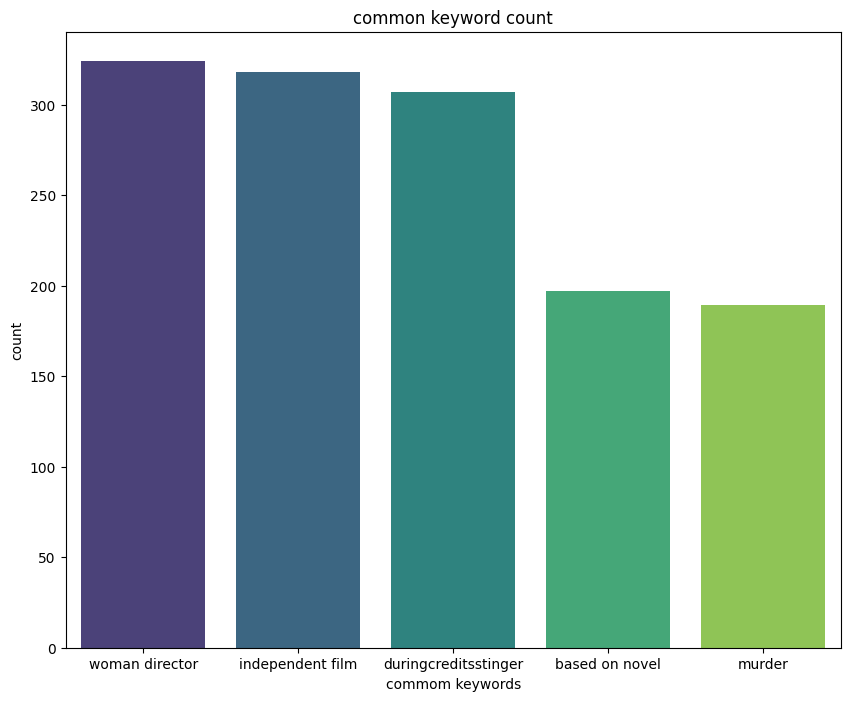

In [8]:
plt.figure(figsize=(10,8))
sns.barplot(keys,palette='viridis')
plt.xlabel('commom keywords')
plt.title('common keyword count')
plt.show()

# Which year has most movie release

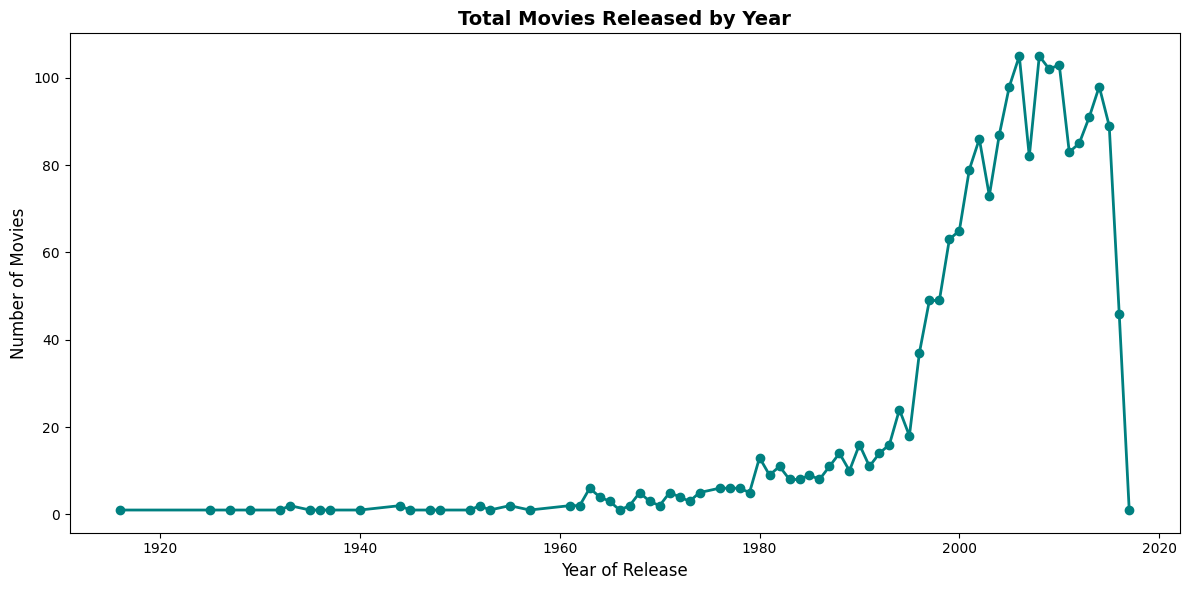

In [10]:
movie['release_date'] = pd.to_datetime(movie['release_date'], errors='coerce')
movie['year'] = movie['release_date'].dt.year
movies_per_year = movie['year'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
plt.plot(movies_per_year.index, movies_per_year.values, marker='o', color='teal', linewidth=2)
plt.title("Total Movies Released by Year", fontsize=14, weight='bold')
plt.xlabel("Year of Release", fontsize=12)
plt.ylabel("Number of Movies", fontsize=12)
plt.tight_layout()
plt.show()


# Which theme is always found from 1980

In [15]:
movie['release_date_parsed'] = pd.to_datetime(movie['release_date'], errors='coerce')
movie['year'] = movie['release_date_parsed'].dt.year
movie = movie[movie['year'] >= 1980]
exploded = movie.explode('keywords')
year_keywords = exploded.groupby('year')['keywords'].apply(lambda s: set(s.dropna()))

if len(year_keywords) == 0:
    common_keywords = set()
else:
    common_keywords = set.intersection(*year_keywords)

print("Years considered:", sorted(year_keywords.index.tolist()))
print("Keywords present in ALL years (1980 onwards):", common_keywords)


Years considered: [1980.0, 1981.0, 1982.0, 1983.0, 1984.0, 1985.0, 1986.0, 1987.0, 1988.0, 1989.0, 1990.0, 1991.0, 1992.0, 1993.0, 1994.0, 1995.0, 1996.0, 1997.0, 1998.0, 1999.0, 2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0, 2015.0, 2016.0, 2017.0]
Keywords present in ALL years (1980 onwards): set()


# Which keyword is consistent in  decade wise

In [18]:
TOP_N = 10 
movie['release_date_parsed'] = pd.to_datetime(movie['release_date'], errors='coerce')
movie['year'] = movie['release_date_parsed'].dt.year
movie = movie[movie['year'].notna() & (movie['year'] >= 1980)].copy()

exploded = movie.explode('keywords')
exploded['decade_start'] = (exploded['year'].astype(int) // 10) * 10
exploded['decade'] = exploded['decade_start'].astype(str) + 's'

decade_top_keywords = {}
for decade, grp in exploded.groupby('decade'):
    counts = grp['keywords'].value_counts().reset_index()
    counts.columns = ['keyword', 'count']
    decade_top_keywords[decade] = counts.head(TOP_N).reset_index(drop=True)

for dec in sorted(decade_top_keywords.keys()):
    print(f"\nTop {TOP_N} keywords in {dec}:")
    print(decade_top_keywords[dec].to_string(index=False))



Top 10 keywords in 1980s:
         keyword  count
independent film      6
      corruption      5
          murder      5
          nudity      5
         slasher      5
     time travel      4
  based on novel      4
         monster      4
           demon      3
         musical      3

Top 10 keywords in 1990s:
         keyword  count
independent film     33
  woman director     21
            love     15
          murder     15
  based on novel     11
             sex     11
        new york     11
      friendship     10
        violence      9
            drug      9

Top 10 keywords in 2000s:
             keyword  count
    independent film     87
      woman director     73
duringcreditsstinger     56
               sport     30
              murder     27
 aftercreditsstinger     26
            violence     23
             revenge     23
      based on novel     23
            dystopia     21

Top 10 keywords in 2010s:
             keyword  count
duringcreditsstinger     62


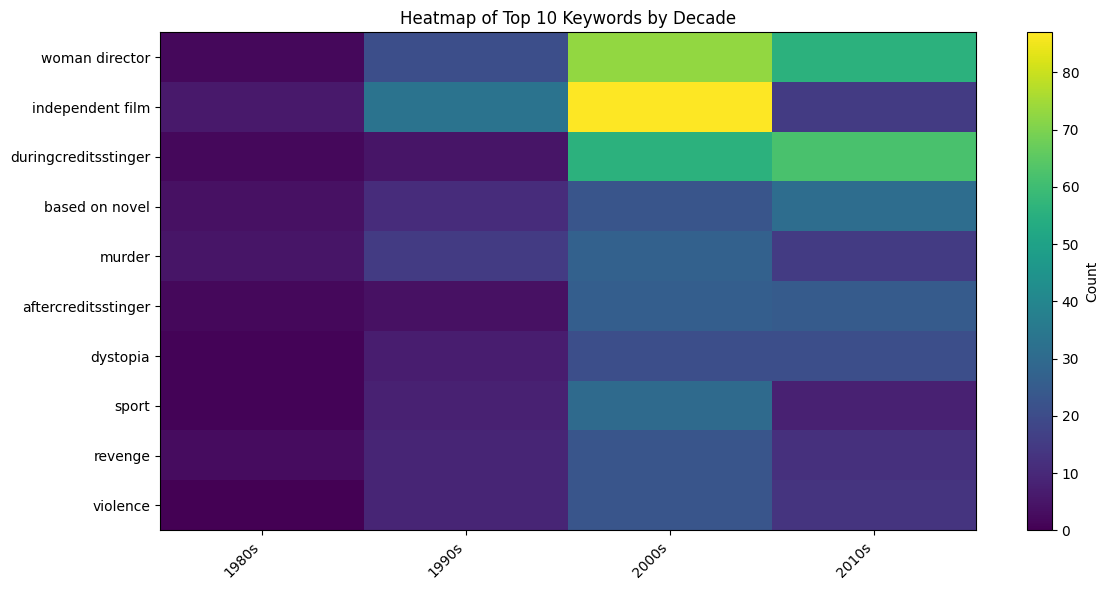

In [19]:

TOP_M = 10 
overall_top = exploded['keywords'].value_counts().head(TOP_M).index.tolist()
pivot = exploded[exploded['keywords'].isin(overall_top)].groupby(['keywords','decade']).size().unstack(fill_value=0)
pivot = pivot.reindex(overall_top)
fig, ax = plt.subplots(figsize=(12, max(6, 0.35 * len(pivot))))
im = ax.imshow(pivot.values, aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Count')
ax.set_title(f"Heatmap of Top {TOP_M} Keywords by Decade")
plt.tight_layout()
plt.show()
